In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:

# ============================================================
# STEP 1 — LOAD THE DATA
# ============================================================

df = pd.read_csv("dataset_large__(50_nodes).csv")

In [3]:
# ============================================================
# STEP 2 — EXPLORE THE DATA (EDA)
# ============================================================
df.dtypes
df.describe()
print("\n  Correlation with travel_time_mins:")
numeric_cols = ["distance_km", "time_of_day", "traffic_factor",
                "road_type", "vehicle_load_pct", "weather_condition"]
correlations = df[numeric_cols + ["travel_time_mins"]].corr()["travel_time_mins"].drop("travel_time_mins")
print(correlations.sort_values(ascending=False).round(3))



  Correlation with travel_time_mins:
distance_km          0.588
traffic_factor       0.276
weather_condition    0.179
vehicle_load_pct     0.039
time_of_day         -0.015
road_type           -0.572
Name: travel_time_mins, dtype: float64


In [4]:
# ============================================================
# STEP 3 — PREPROCESS
# ============================================================
print("\n" + "-"*60)
print("STEP 3: Preprocessing")
print("-"*60)

FEATURE_COLS = [
    "distance_km",
    "time_of_day",
    "traffic_factor",
    "road_type",
    "vehicle_load_pct",
    "weather_condition",
]
TARGET_COL = "travel_time_mins"

X = df[FEATURE_COLS]
y = df[TARGET_COL]

print(f"\n  3a. Features selected : {FEATURE_COLS}")
print(f"      Target            : {TARGET_COL}")
print(f"      Dataset shape     : {X.shape}")

# Handle missing values
missing = X.isnull().sum().sum()
print(f"\n  3b. Missing values: {missing}")
if missing > 0:
    X = X.fillna(X.median())
    print("      Filled with column medians")
else:
    print("      None found — dataset is clean")

print("\n  NOTE: No scaling needed for Random Forest.")
print("        Tree-based models are scale-invariant.")



------------------------------------------------------------
STEP 3: Preprocessing
------------------------------------------------------------

  3a. Features selected : ['distance_km', 'time_of_day', 'traffic_factor', 'road_type', 'vehicle_load_pct', 'weather_condition']
      Target            : travel_time_mins
      Dataset shape     : (10000, 6)

  3b. Missing values: 0
      None found — dataset is clean

  NOTE: No scaling needed for Random Forest.
        Tree-based models are scale-invariant.


In [5]:
# ============================================================
# STEP 4 — TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20,random_state=42)

In [6]:
# ============================================================
# STEP 5 — TRAIN THE RANDOM FOREST MODEL
# ============================================================
# Key hyperparameters:
#   n_estimators  — number of trees (more = more stable, slower)
#   max_depth     — how deep each tree grows (None = unlimited)
#   min_samples_split — minimum samples to split a node
#   random_state  — for reproducibility
#
# These values are well-established defaults for logistics regression.
# In a more advanced thesis you would tune them using GridSearchCV.

print("\n" + "-"*60)
print("STEP 5: Training Random Forest model")
print("-"*60)

model = RandomForestRegressor(
    n_estimators=100,       # 100 decision trees
    max_depth=None,         # trees grow until leaves are pure
    min_samples_split=2,    # split node if at least 2 samples
    min_samples_leaf=1,     # each leaf must have at least 1 sample
    random_state=42,
    n_jobs=-1               # use all CPU cores for speed
)

print("  Training 100 decision trees...")
model.fit(X_train, y_train)


------------------------------------------------------------
STEP 5: Training Random Forest model
------------------------------------------------------------
  Training 100 decision trees...


,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [7]:
# ============================================================
# STEP 6 — EVALUATE THE MODEL
# ============================================================

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\n  MAE  (Mean Absolute Error)         : {mae:.4f} minutes")
print(f"       → predictions off by {mae:.2f} mins on average")
print(f"\n  RMSE (Root Mean Squared Error)     : {rmse:.4f} minutes")
print(f"       → large errors penalised, {rmse:.2f} mins spread")
print(f"\n  R²   (Coefficient of Determination): {r2:.4f}")
print(f"       → model explains {r2*100:.1f}% of travel time variation")

# Cross validation
cv_scores = cross_val_score(
    RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    X, y, cv=5, scoring="r2"
)
print(f"\n  5-Fold Cross-Validation R²:")
print(f"    Scores : {[round(s, 4) for s in cv_scores]}")
print(f"    Mean   : {cv_scores.mean():.4f}")
print(f"    Std    : {cv_scores.std():.4f}")


  MAE  (Mean Absolute Error)         : 5.6395 minutes
       → predictions off by 5.64 mins on average

  RMSE (Root Mean Squared Error)     : 9.2240 minutes
       → large errors penalised, 9.22 mins spread

  R²   (Coefficient of Determination): 0.9432
       → model explains 94.3% of travel time variation

  5-Fold Cross-Validation R²:
    Scores : [np.float64(0.9426), np.float64(0.95), np.float64(0.9464), np.float64(0.9482), np.float64(0.9447)]
    Mean   : 0.9464
    Std    : 0.0026


In [8]:
# ============================================================
# STEP 7 — FEATURE IMPORTANCE ANALYSIS
# ============================================================
# Random Forest tells you HOW MUCH each feature contributed
# to reducing prediction error across all trees.

print("\n" + "-"*60)
print("STEP 7: Feature Importance Analysis")
print("-"*60)

importances = model.feature_importances_
importance_df = pd.DataFrame({"Feature": FEATURE_COLS,"Importance": importances}).sort_values("Importance", ascending=False)

print("\n  Feature importances (higher = more influential):")
for _, row in importance_df.iterrows():
    bar = "█" * int(row["Importance"] * 50)
    print(f"    {row['Feature']:20s}: {row['Importance']:.4f}  {bar}")



------------------------------------------------------------
STEP 7: Feature Importance Analysis
------------------------------------------------------------

  Feature importances (higher = more influential):
    distance_km         : 0.4535  ██████████████████████
    road_type           : 0.3525  █████████████████
    traffic_factor      : 0.1223  ██████
    weather_condition   : 0.0458  ██
    vehicle_load_pct    : 0.0168  
    time_of_day         : 0.0092  



------------------------------------------------------------
STEP 8: Visualising Results
------------------------------------------------------------
  Saved: random_forest_evaluation.png


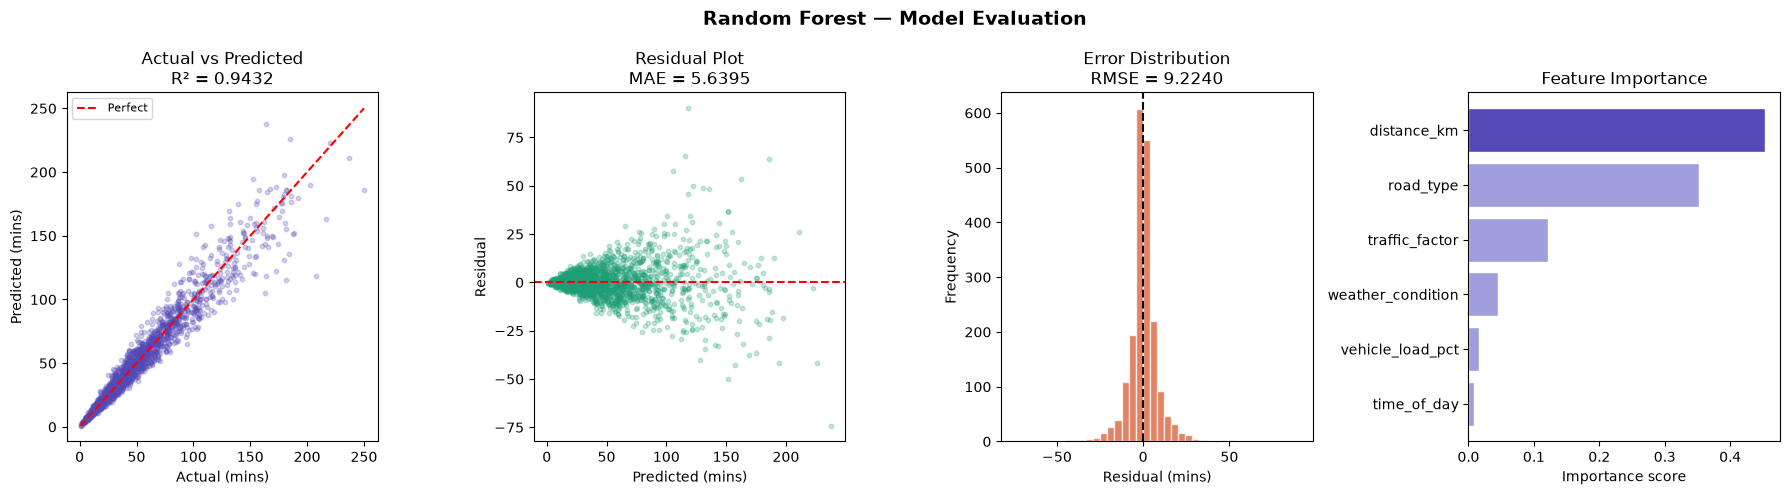

In [9]:
# ============================================================
# STEP 8 — VISUALISE RESULTS
# ============================================================

print("\n" + "-"*60)
print("STEP 8: Visualising Results")
print("-"*60)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Random Forest — Model Evaluation", fontsize=14, fontweight="bold")

# Plot 1: Actual vs Predicted
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.25, s=10, color="#534AB7")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], "r--", lw=1.5, label="Perfect")
ax.set_xlabel("Actual (mins)")
ax.set_ylabel("Predicted (mins)")
ax.set_title(f"Actual vs Predicted\nR² = {r2:.4f}")
ax.legend(fontsize=8)

# Plot 2: Residuals
residuals = y_test - y_pred
ax = axes[1]
ax.scatter(y_pred, residuals, alpha=0.25, s=10, color="#1D9E75")
ax.axhline(0, color="red", linestyle="--", lw=1.5)
ax.set_xlabel("Predicted (mins)")
ax.set_ylabel("Residual")
ax.set_title(f"Residual Plot\nMAE = {mae:.4f}")

# Plot 3: Residual distribution
ax = axes[2]
ax.hist(residuals, bins=40, color="#D85A30", alpha=0.75, edgecolor="white")
ax.axvline(0, color="black", linestyle="--", lw=1.5)
ax.set_xlabel("Residual (mins)")
ax.set_ylabel("Frequency")
ax.set_title(f"Error Distribution\nRMSE = {rmse:.4f}")

# Plot 4: Feature importance
ax = axes[3]
colors = ["#534AB7" if i == 0 else "#A09EDD"
          for i in range(len(importance_df))]
ax.barh(importance_df["Feature"], importance_df["Importance"],
        color=colors, edgecolor="white")
ax.set_xlabel("Importance score")
ax.set_title("Feature Importance")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("random_forest_evaluation.png", dpi=150, bbox_inches="tight")
print("  Saved: random_forest_evaluation.png")
plt.show()


In [10]:
# ============================================================
# STEP 9 — SAVE THE MODEL
# ============================================================

print("\n" + "-"*60)
print("STEP 9: Saving Model")
print("-"*60)

joblib.dump(model, "random_forest_model_50.pkl")

print("  Saved: random_forest_model_50.pkl")


print("\n" + "="*60)
print("  RANDOM FOREST COMPLETE")
print(f"  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
print("="*60 + "\n")


------------------------------------------------------------
STEP 9: Saving Model
------------------------------------------------------------
  Saved: random_forest_model_50.pkl

  RANDOM FOREST COMPLETE
  MAE=5.6395  RMSE=9.2240  R²=0.9432

